Columns:
 Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

First 5 rows:
    longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY

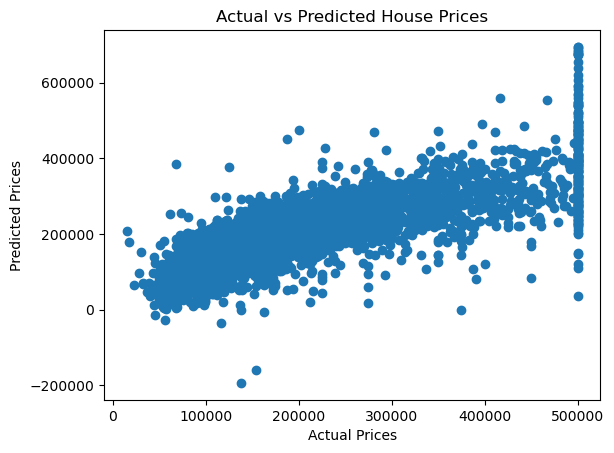

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv(r"C:\Users\91739\Downloads\archive (9)\housing.csv")
print("Columns:\n", df.columns)
print("\nFirst 5 rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]
X = pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)
feature_names = X.columns
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nModel Performance:")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)
coeff_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_
})
print("\nFeature Importance (Sorted):")
print(coeff_df.sort_values(by="Coefficient", ascending=False))
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()